## 1. Setup & Configuration

In [10]:
# Core libraries
import os
import sys
import json
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model

# Metrics for ROC-AUC
from sklearn.metrics import (
    roc_curve, auc, classification_report, confusion_matrix,
    accuracy_score, precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Suppress warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

✅ All libraries imported successfully!
TensorFlow version: 2.15.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Path Configuration

In [11]:
# ============================================
# PATH CONFIGURATION
# ============================================

DATASET_NAME = 'MangoLeafBD'

# Workspace paths
WORKSPACE_DIR = Path('/Users/invictus/Desktop/Thesis project/thesis_draft')
DATASETS_BASE = WORKSPACE_DIR / 'datasets'
DATA_DIR  = DATASETS_BASE / DATASET_NAME / 'processed'
TEST_DIR  = DATA_DIR / 'test'

# Experiments directory (where trained models are saved)
EXPERIMENTS_ROOT = WORKSPACE_DIR / DATASET_NAME / 'experiments'
OUTPUTS_ROOT = WORKSPACE_DIR / DATASET_NAME / 'outputs'

# Display configuration
print("="*60)
print("📁 PATH CONFIGURATION")
print("="*60)
print(f"Workspace      : {WORKSPACE_DIR}")
print(f"Dataset Name   : {DATASET_NAME}")
print(f"Data Directory : {DATA_DIR}")
print(f"Test Directory : {TEST_DIR}")
print(f"Experiments    : {EXPERIMENTS_ROOT}")
print("="*60)

# Verify test directory exists
if TEST_DIR.exists():
    print(f"✅ Test directory exists")
else:
    print(f"❌ Test directory NOT FOUND: {TEST_DIR}")

📁 PATH CONFIGURATION
Workspace      : /Users/invictus/Desktop/Thesis project/thesis_draft
Dataset Name   : MangoLeafBD
Data Directory : /Users/invictus/Desktop/Thesis project/thesis_draft/datasets/MangoLeafBD/processed
Test Directory : /Users/invictus/Desktop/Thesis project/thesis_draft/datasets/MangoLeafBD/processed/test
Experiments    : /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/experiments
✅ Test directory exists


## 3. Helper Functions

In [12]:
def get_latest_run_dir(model_name):
    """
    Find the latest run directory for a given model.
    Returns the path to the directory with the highest run number.
    """
    model_dir = EXPERIMENTS_ROOT / model_name
    if not model_dir.exists():
        print(f"❌ Model directory not found: {model_dir}")
        return None
    
    run_dirs = [d for d in model_dir.iterdir() 
                if d.is_dir() and d.name.startswith('run_')]
    
    if not run_dirs:
        print(f"❌ No run directories found for {model_name}")
        return None
    
    # Sort by run number and get the latest
    run_dirs.sort(key=lambda x: int(x.name.split('_')[1]))
    latest_run = run_dirs[-1]
    
    return latest_run


def load_model_and_info(model_name):
    """
    Load the trained model and its metadata from the latest run.
    Returns: model, model_info, classes, run_dir
    """
    run_dir = get_latest_run_dir(model_name)
    if run_dir is None:
        return None, None, None, None
    
    print(f"\n📂 Loading {model_name} from: {run_dir.name}")
    
    # Find model file (.h5)
    model_files = list(run_dir.glob('*.h5'))
    if not model_files:
        print(f"❌ No .h5 model file found in {run_dir}")
        return None, None, None, None
    
    model_path = model_files[0]
    
    # Load model
    print(f"   Loading model: {model_path.name}")
    model = load_model(model_path, compile=False)
    
    # Load model info
    model_info_path = run_dir / 'model_info.json'
    model_info = None
    if model_info_path.exists():
        with open(model_info_path, 'r') as f:
            model_info = json.load(f)
        print(f"   ✅ Model info loaded")
    
    # Load classes
    classes_path = run_dir / 'classes.json'
    classes = None
    if classes_path.exists():
        with open(classes_path, 'r') as f:
            classes = json.load(f)
        print(f"   ✅ Classes loaded: {len(classes)} classes")
    
    return model, model_info, classes, run_dir


# ============================================
# PREPROCESSING FUNCTIONS FOR DIFFERENT MODELS
# ============================================

# ImageNet statistics (for ResNet50, VGG16, VGG19)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def imagenet_preprocess(image):
    """Normalize image using ImageNet mean and std (for ResNet50, VGG16, VGG19)"""
    image = image / 255.0  # Scale to [0, 1]
    image = (image - IMAGENET_MEAN) / IMAGENET_STD  # Normalize
    return image


def create_test_generator(img_size, model_name, batch_size=32):
    """
    Create test data generator with model-specific preprocessing.
    
    Different models require different preprocessing (MUST MATCH TRAINING):
    - AlexNet: Simple rescale (1/255)
    - ResNet50_Simple: ImageNet normalization (mean/std)
    - RESNET50_Pretrained: ImageNet normalization (mean/std)
    - VGG16: Simple rescale (1/255) - trained with rescale, NOT ImageNet norm!
    - VGG19: Simple rescale (1/255) - trained with rescale, NOT ImageNet norm!
    """
    # Determine preprocessing based on model name
    # ONLY ResNet50 models use ImageNet normalization
    if model_name in ['ResNet50_Simple', 'RESNET50_Pretrained']:
        print(f"   📌 Using ImageNet preprocessing (mean/std normalization)")
        test_datagen = ImageDataGenerator(preprocessing_function=imagenet_preprocess)
    else:
        # AlexNet, VGG16, VGG19 and other custom models use simple rescale
        print(f"   📌 Using simple preprocessing (rescale 1/255)")
        test_datagen = ImageDataGenerator(rescale=1./255)
    
    test_generator = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=(img_size, img_size),
        batch_size=batch_size,
        class_mode='categorical',
        shuffle=False  # Important for evaluation!
    )
    
    return test_generator


print("✅ Helper functions defined (with model-specific preprocessing)")

✅ Helper functions defined (with model-specific preprocessing)


## 4. ROC-AUC Analysis Functions

In [13]:
def generate_roc_auc_analysis(model, model_name, test_generator, classes, output_dir):
    """
    Generate complete ROC-AUC analysis for a model.
    
    Args:
        model: Loaded Keras model
        model_name: Name of the model (for titles)
        test_generator: Test data generator
        classes: List of class names
        output_dir: Directory to save outputs
    """
    print("="*80)
    print(f"📊 ROC CURVE & AUC ANALYSIS - {model_name}")
    print("="*80)
    
    # Get predictions
    print("\n🔄 Generating predictions on test set...")
    test_generator.reset()
    y_pred_probs = model.predict(test_generator, verbose=1)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = test_generator.classes
    
    n_classes = len(classes)
    idx2name = classes
    
    # Print basic accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"\n📈 Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    # Binarize the labels for One-vs-Rest approach
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    
    # Compute ROC curve and AUC for each class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute micro-average ROC curve and AUC
    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_pred_probs.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    
    # ============================================
    # Plot 1: Combined ROC Curves for All Classes
    # ============================================
    
    plt.figure(figsize=(12, 10))
    
    # Plot ROC curve for each class with thick lines
    colors = cycle(['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
                    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])
    
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=3,
                 label=f'{idx2name[i]} (AUC = {roc_auc[i]:.3f})')
    
    # Plot diagonal (random classifier baseline)
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.500)')
    
    # Formatting
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
    plt.title(f'ROC Curve and AUC per Class for {model_name}', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11, framealpha=0.95)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    # Save combined ROC plot
    combined_path = output_dir / f'roc_curve_combined_{model_name}.png'
    plt.savefig(combined_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Combined ROC curve saved to: {combined_path}")
    
    # ============================================
    # Plot 2: Individual ROC Curves (2x4 grid)
    # ============================================
    
    n_cols = 4
    n_rows = (n_classes + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = axes.ravel()
    
    for i in range(n_classes):
        axes[i].plot(fpr[i], tpr[i], color='darkorange', lw=3,
                     label=f'ROC curve (AUC = {roc_auc[i]:.3f})')
        axes[i].plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
        axes[i].set_xlim([0.0, 1.0])
        axes[i].set_ylim([0.0, 1.05])
        axes[i].set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
        axes[i].set_title(f'{idx2name[i]}', fontsize=13, fontweight='bold')
        axes[i].legend(loc="lower right", fontsize=10)
        axes[i].grid(alpha=0.3)
    
    # Hide unused subplots
    for i in range(n_classes, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'ROC Curves per Class - {model_name}', fontsize=18, fontweight='bold')
    plt.tight_layout()
    
    # Save individual ROC plots
    individual_path = output_dir / f'roc_curves_individual_{model_name}.png'
    plt.savefig(individual_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Individual ROC curves saved to: {individual_path}")
    
    # ============================================
    # AUC Scores Table
    # ============================================
    
    auc_df = pd.DataFrame({
        'Class': idx2name,
        'AUC Score': [roc_auc[i] for i in range(n_classes)]
    })
    
    # Add summary statistics
    auc_summary = pd.DataFrame({
        'Class': ['Micro-Average', 'Macro-Average', 'Min', 'Max'],
        'AUC Score': [
            roc_auc["micro"],
            np.mean([roc_auc[i] for i in range(n_classes)]),
            np.min([roc_auc[i] for i in range(n_classes)]),
            np.max([roc_auc[i] for i in range(n_classes)])
        ]
    })
    
    print("\n" + "="*80)
    print(f"📊 AUC SCORES PER CLASS - {model_name}")
    print("="*80)
    print(auc_df.to_string(index=False))
    print("\n" + "-"*80)
    print("SUMMARY STATISTICS")
    print("-"*80)
    print(auc_summary.to_string(index=False))
    print("="*80)
    
    # Save AUC scores
    auc_df.to_csv(output_dir / f'auc_scores_{model_name}.csv', index=False)
    print(f"\n✅ AUC scores saved to: {output_dir / f'auc_scores_{model_name}.csv'}")
    
    # Save summary statistics
    auc_summary.to_csv(output_dir / f'auc_summary_{model_name}.csv', index=False)
    print(f"✅ AUC summary saved to: {output_dir / f'auc_summary_{model_name}.csv'}")
    
    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc,
        'auc_df': auc_df,
        'auc_summary': auc_summary
    }

print("✅ ROC-AUC analysis function defined")

✅ ROC-AUC analysis function defined


## 5. Select Model to Analyze

Choose which model(s) to generate ROC curves for.

In [14]:
# ============================================
# SELECT MODEL TO ANALYZE
# ============================================

# Available models (change this to analyze different models)
AVAILABLE_MODELS = ['AlexNet', 'ResNet50_Simple', 'VGG16', 'VGG19']

# Select which model to analyze (change this value)
# Options: 'AlexNet', 'ResNet50_Simple', 'VGG16', 'VGG19', or 'ALL'
SELECTED_MODEL = 'ALL'  # Change to specific model name or 'ALL'

print("="*60)
print("📋 MODEL SELECTION")
print("="*60)
print(f"Available models: {AVAILABLE_MODELS}")
print(f"Selected: {SELECTED_MODEL}")
print("="*60)

# List available experiments
print("\n📂 Available experiments in directory:")
if EXPERIMENTS_ROOT.exists():
    for model_dir in sorted(EXPERIMENTS_ROOT.iterdir()):
        if model_dir.is_dir() and not model_dir.name.startswith('.'):
            runs = [d.name for d in model_dir.iterdir() if d.is_dir() and d.name.startswith('run_')]
            runs.sort(key=lambda x: int(x.split('_')[1]))
            if runs:
                print(f"   {model_dir.name}: {runs}")
else:
    print(f"   ❌ Experiments directory not found: {EXPERIMENTS_ROOT}")

📋 MODEL SELECTION
Available models: ['AlexNet', 'ResNet50_Simple', 'VGG16', 'VGG19']
Selected: ALL

📂 Available experiments in directory:
   AlexNet: ['run_1', 'run_2', 'run_3']
   MangoXPPNet: ['run_7', 'run_8']
   RESNET50_Pretrained: ['run_1']
   ResNet50_Simple: ['run_1', 'run_13', 'run_15']
   VGG16: ['run_1', 'run_2', 'run_3']
   VGG19: ['run_1', 'run_2']


## 6. Generate ROC-AUC Analysis


################################################################################
# Processing: AlexNet
################################################################################

📂 Loading AlexNet from: run_3
   Loading model: AlexNet_MangoLeafBD_best.h5
   ✅ Model info loaded
   ✅ Classes loaded: 8 classes
   Image size: 227x227
   Output dir: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/AlexNet/run_3
   📌 Using simple preprocessing (rescale 1/255)
Found 400 images belonging to 8 classes.
   ✅ Model info loaded
   ✅ Classes loaded: 8 classes
   Image size: 227x227
   Output dir: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/AlexNet/run_3
   📌 Using simple preprocessing (rescale 1/255)
Found 400 images belonging to 8 classes.
📊 ROC CURVE & AUC ANALYSIS - AlexNet

🔄 Generating predictions on test set...
 1/13 [=>............................] - ETA: 1s==============================================================================

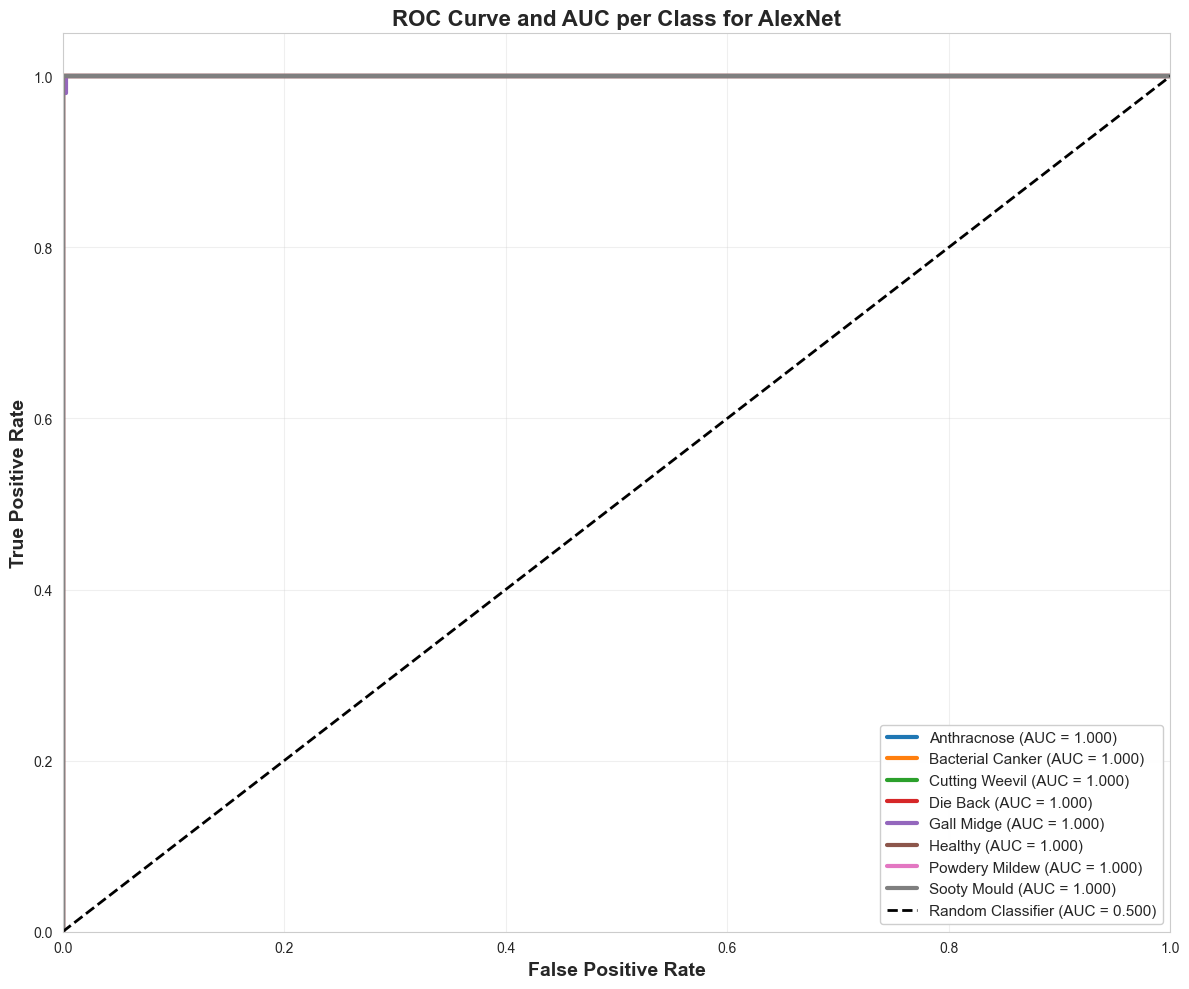

✅ Combined ROC curve saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/AlexNet/run_3/roc_curve_combined_AlexNet.png


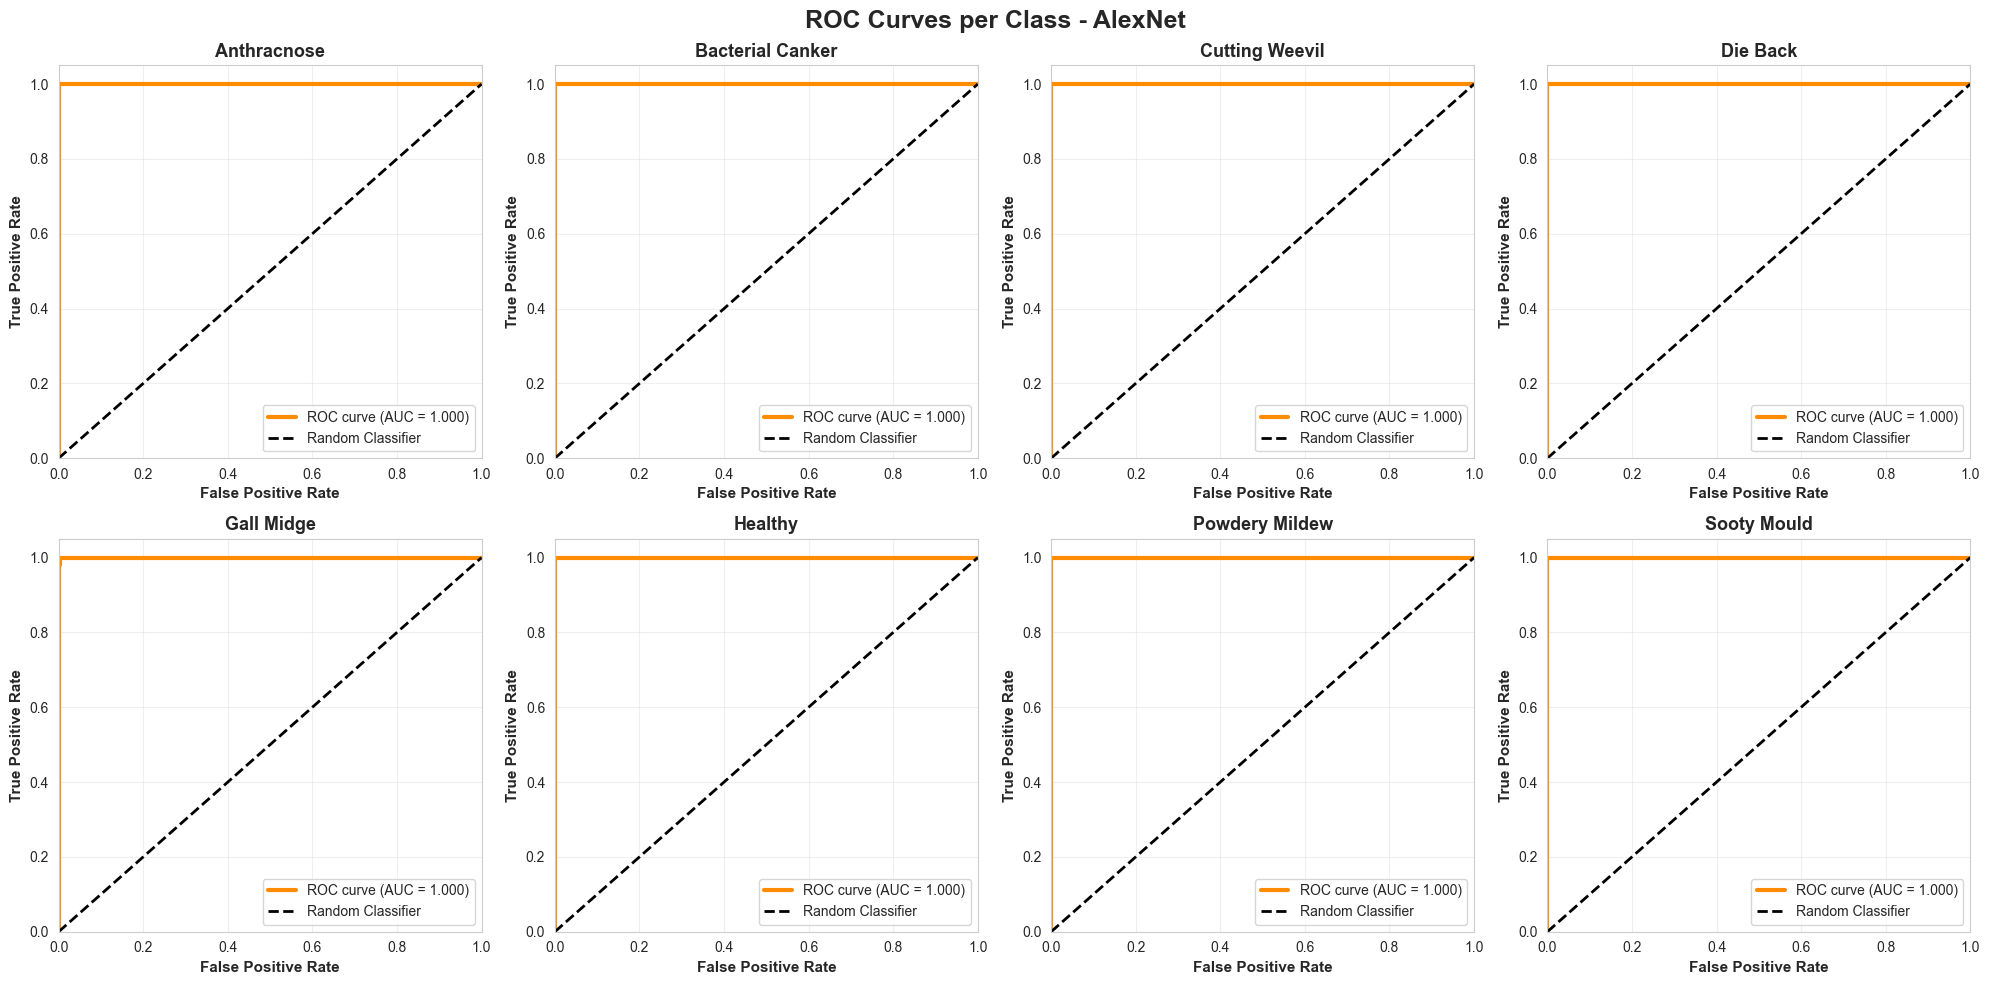

✅ Individual ROC curves saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/AlexNet/run_3/roc_curves_individual_AlexNet.png

📊 AUC SCORES PER CLASS - AlexNet
           Class  AUC Score
     Anthracnose   1.000000
Bacterial Canker   1.000000
  Cutting Weevil   1.000000
        Die Back   1.000000
      Gall Midge   0.999943
         Healthy   1.000000
  Powdery Mildew   1.000000
     Sooty Mould   1.000000

--------------------------------------------------------------------------------
SUMMARY STATISTICS
--------------------------------------------------------------------------------
        Class  AUC Score
Micro-Average   0.999996
Macro-Average   0.999993
          Min   0.999943
          Max   1.000000

✅ AUC scores saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/AlexNet/run_3/auc_scores_AlexNet.csv
✅ AUC summary saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/AlexNet/run_3/auc_summar

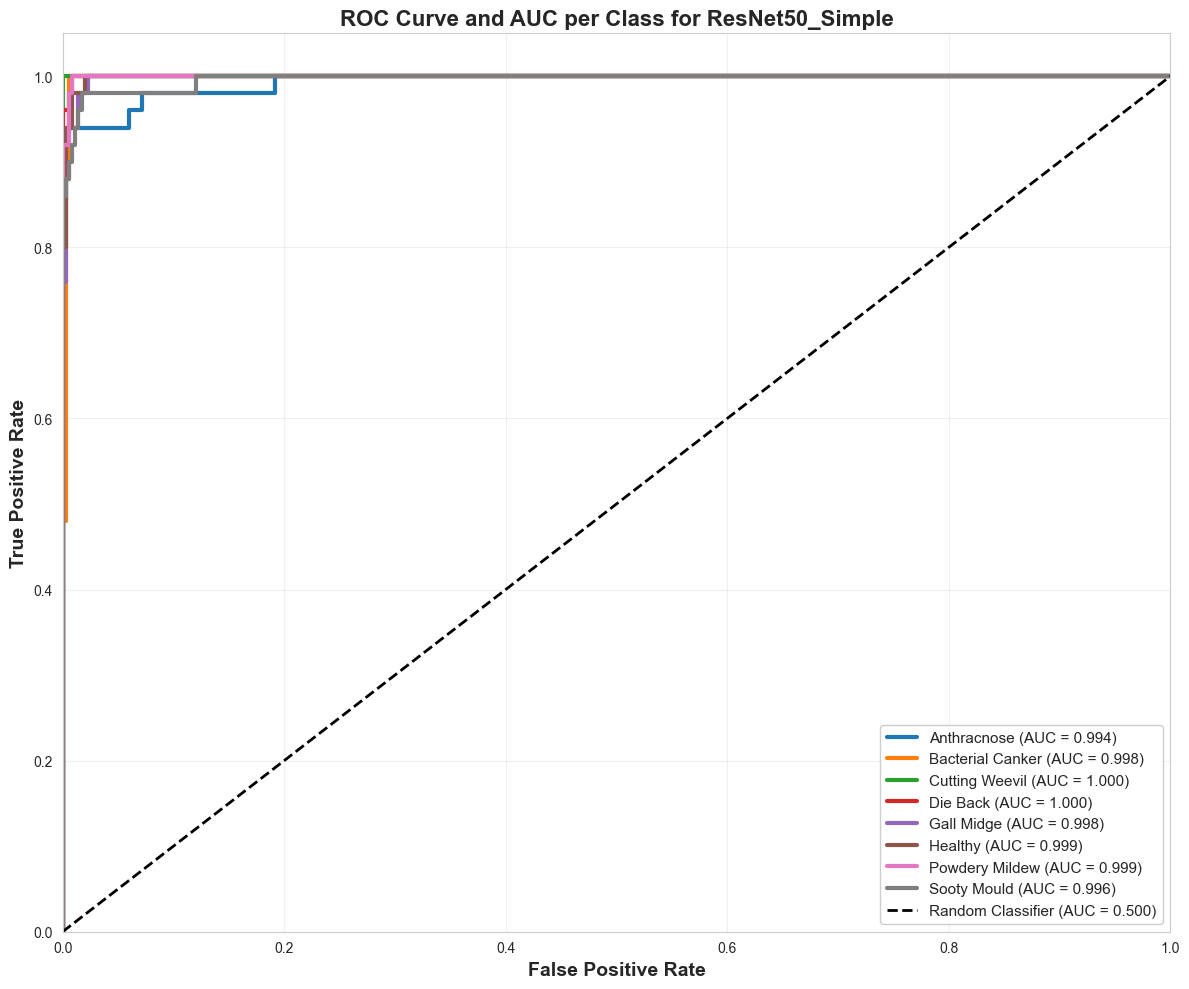

✅ Combined ROC curve saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/ResNet50_Simple/run_15/roc_curve_combined_ResNet50_Simple.png


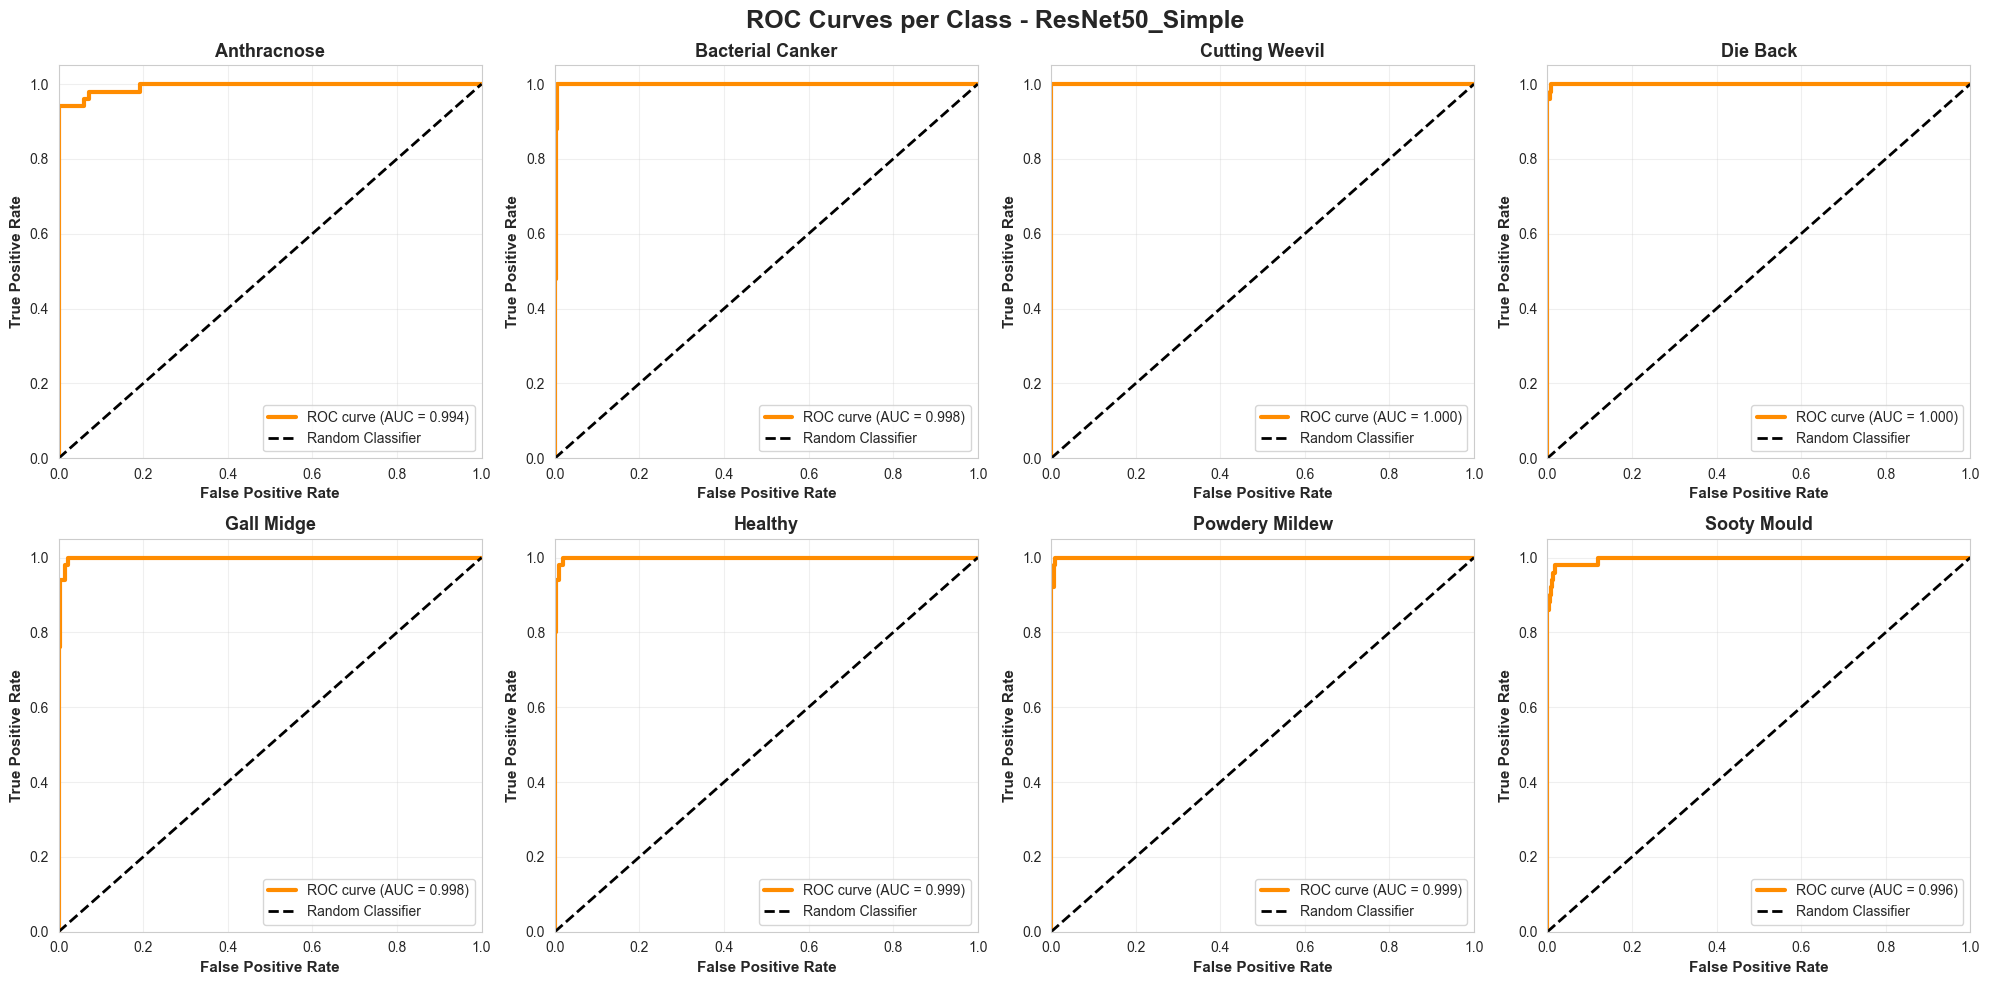

✅ Individual ROC curves saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/ResNet50_Simple/run_15/roc_curves_individual_ResNet50_Simple.png

📊 AUC SCORES PER CLASS - ResNet50_Simple
           Class  AUC Score
     Anthracnose   0.993543
Bacterial Canker   0.998171
  Cutting Weevil   1.000000
        Die Back   0.999714
      Gall Midge   0.998457
         Healthy   0.998857
  Powdery Mildew   0.999486
     Sooty Mould   0.996400

--------------------------------------------------------------------------------
SUMMARY STATISTICS
--------------------------------------------------------------------------------
        Class  AUC Score
Micro-Average   0.998235
Macro-Average   0.998079
          Min   0.993543
          Max   1.000000

✅ AUC scores saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/ResNet50_Simple/run_15/auc_scores_ResNet50_Simple.csv
✅ AUC summary saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/Ma

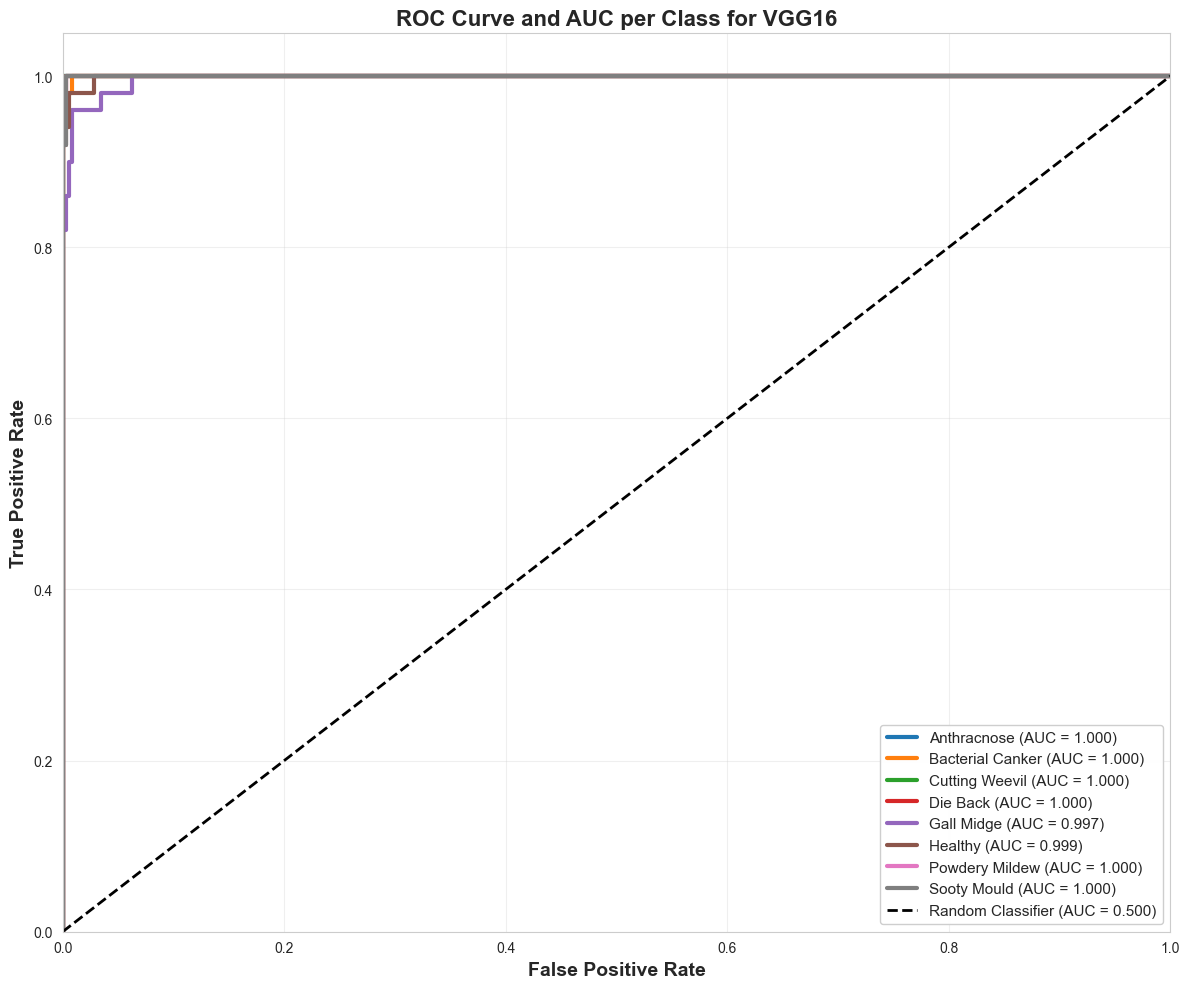

✅ Combined ROC curve saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/VGG16/run_3/roc_curve_combined_VGG16.png


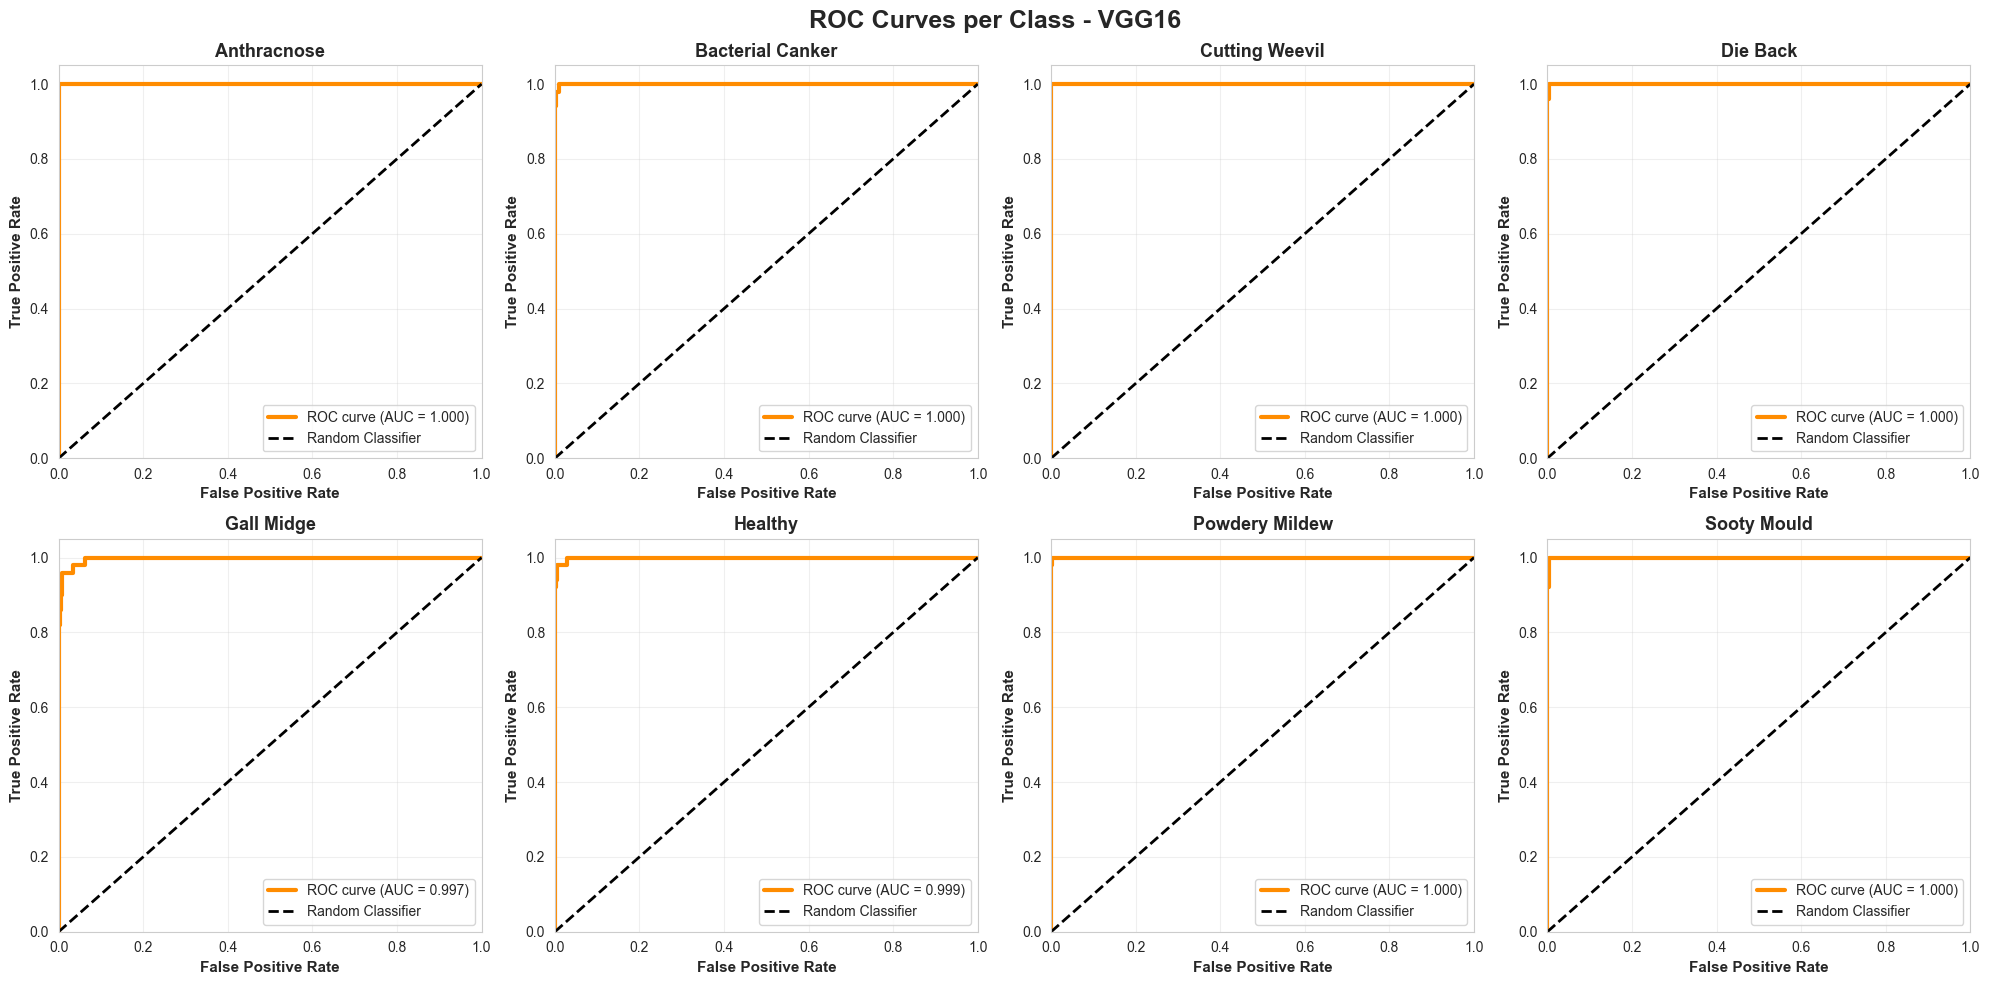

✅ Individual ROC curves saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/VGG16/run_3/roc_curves_individual_VGG16.png

📊 AUC SCORES PER CLASS - VGG16
           Class  AUC Score
     Anthracnose   1.000000
Bacterial Canker   0.999714
  Cutting Weevil   1.000000
        Die Back   0.999886
      Gall Midge   0.997200
         Healthy   0.999143
  Powdery Mildew   0.999943
     Sooty Mould   0.999771

--------------------------------------------------------------------------------
SUMMARY STATISTICS
--------------------------------------------------------------------------------
        Class  AUC Score
Micro-Average   0.999447
Macro-Average   0.999457
          Min   0.997200
          Max   1.000000

✅ AUC scores saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/VGG16/run_3/auc_scores_VGG16.csv
✅ AUC summary saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/VGG16/run_3/auc_summary_VGG16.csv


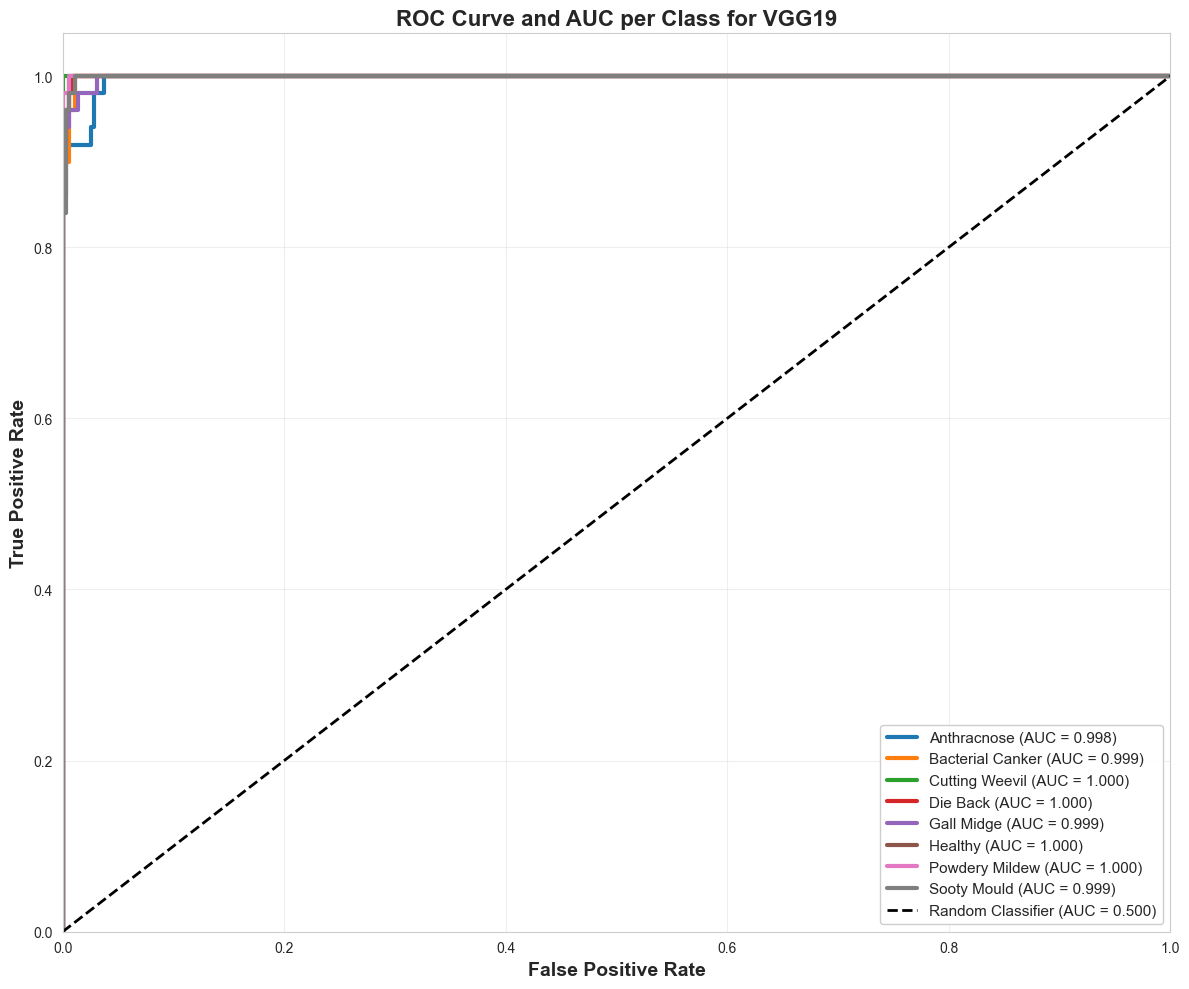

✅ Combined ROC curve saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/VGG19/run_2/roc_curve_combined_VGG19.png


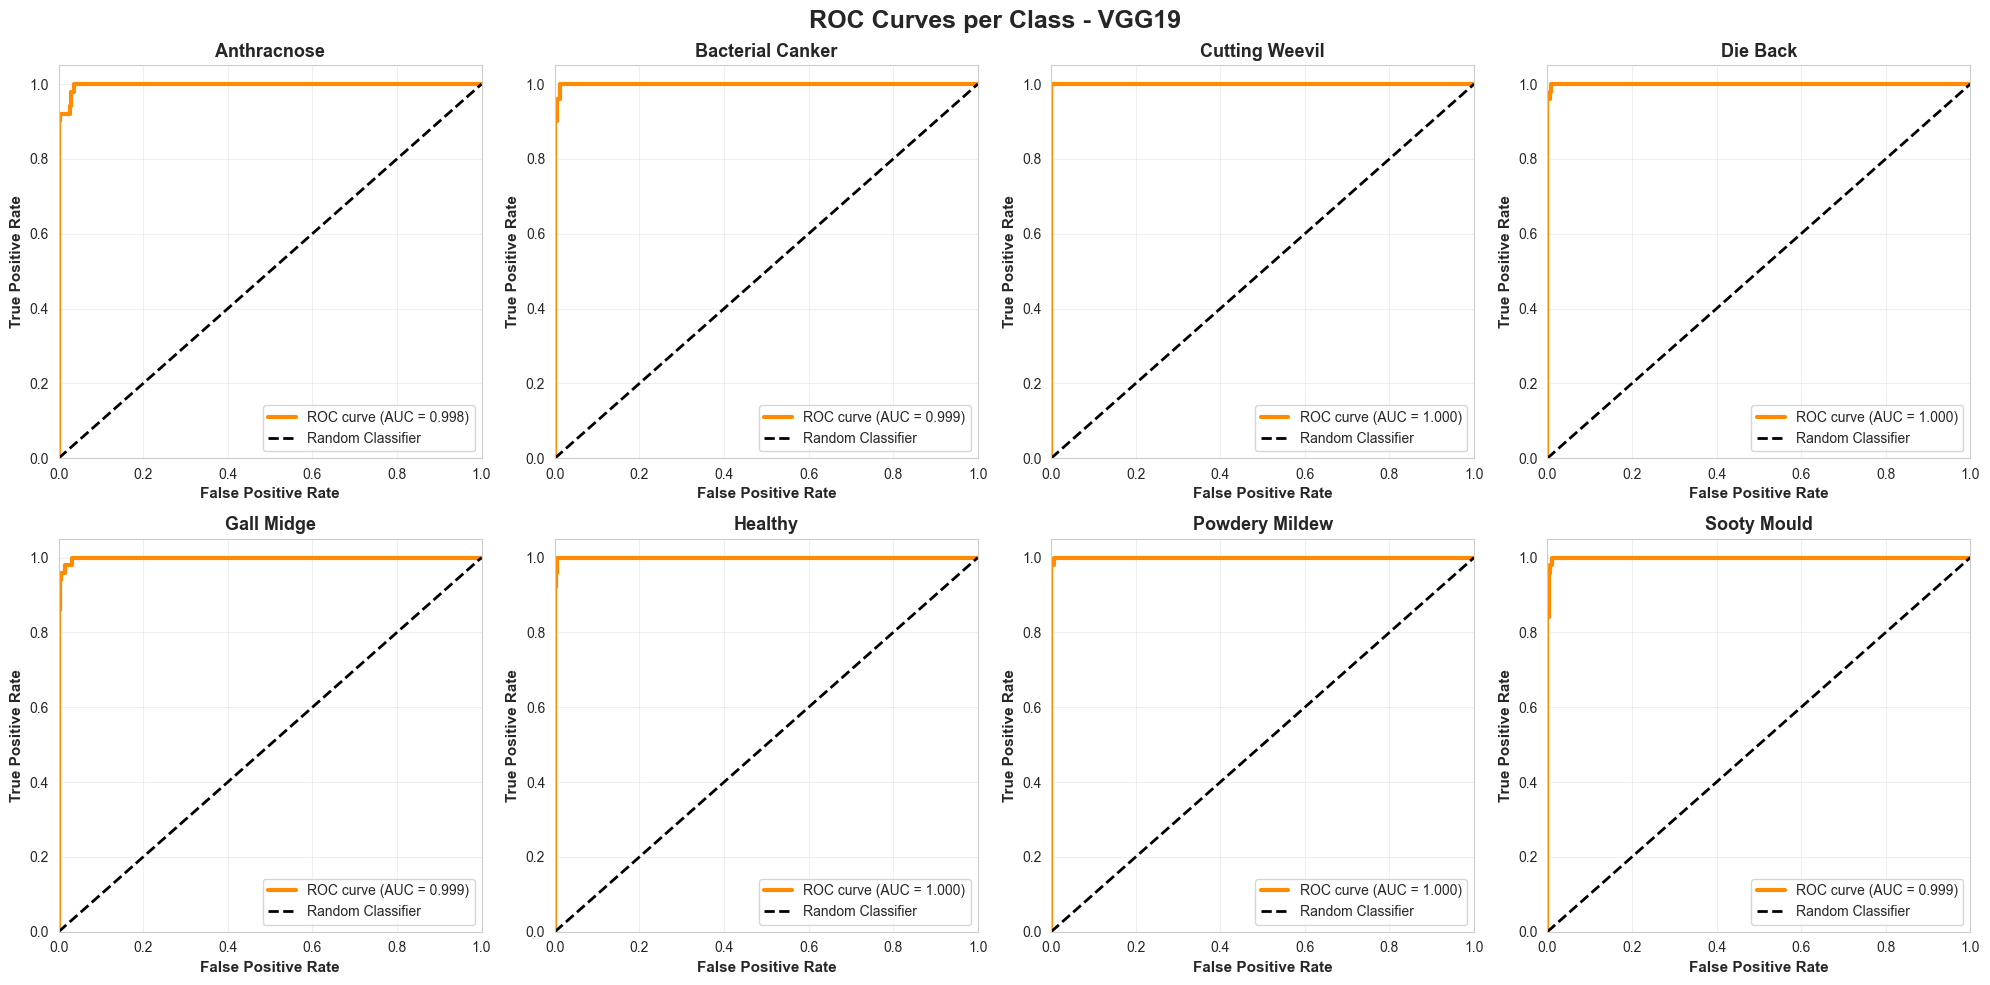

✅ Individual ROC curves saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/VGG19/run_2/roc_curves_individual_VGG19.png

📊 AUC SCORES PER CLASS - VGG19
           Class  AUC Score
     Anthracnose   0.997543
Bacterial Canker   0.999200
  Cutting Weevil   1.000000
        Die Back   0.999714
      Gall Midge   0.998743
         Healthy   0.999657
  Powdery Mildew   0.999886
     Sooty Mould   0.999314

--------------------------------------------------------------------------------
SUMMARY STATISTICS
--------------------------------------------------------------------------------
        Class  AUC Score
Micro-Average   0.999246
Macro-Average   0.999257
          Min   0.997543
          Max   1.000000

✅ AUC scores saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/VGG19/run_2/auc_scores_VGG19.csv
✅ AUC summary saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/VGG19/run_2/auc_summary_VGG19.csv


In [15]:
# ============================================
# GENERATE ROC-AUC ANALYSIS
# ============================================

# Determine which models to process
if SELECTED_MODEL == 'ALL':
    models_to_process = AVAILABLE_MODELS
else:
    models_to_process = [SELECTED_MODEL]

# Store all results
all_results = {}

for model_name in models_to_process:
    print("\n" + "#"*80)
    print(f"# Processing: {model_name}")
    print("#"*80)
    
    # Load model
    model, model_info, classes, run_dir = load_model_and_info(model_name)
    
    if model is None:
        print(f"⚠️ Skipping {model_name} - model not found")
        continue
    
    # Get image size from model info or use default
    if model_info and 'input_shape' in model_info:
        img_size = model_info['input_shape'][0]
    else:
        # Default sizes based on model
        img_size = 227 if model_name == 'AlexNet' else 224
    
    print(f"   Image size: {img_size}x{img_size}")
    
    # Create output directory for this model
    output_dir = OUTPUTS_ROOT / model_name / run_dir.name
    output_dir.mkdir(parents=True, exist_ok=True)
    print(f"   Output dir: {output_dir}")
    
    # Create test generator with model-specific preprocessing
    test_generator = create_test_generator(img_size, model_name)
    
    # Generate ROC-AUC analysis
    results = generate_roc_auc_analysis(
        model=model,
        model_name=model_name,
        test_generator=test_generator,
        classes=classes,
        output_dir=output_dir
    )
    
    all_results[model_name] = results
    
    # Clear memory
    del model
    tf.keras.backend.clear_session()

print("\n" + "="*80)
print("✅ ROC-AUC ANALYSIS COMPLETE FOR ALL SELECTED MODELS")
print("="*80)

## 7. Comparison Summary (All Models)

📊 MODEL COMPARISON SUMMARY
          Model Accuracy Micro-Avg AUC Macro-Avg AUC
        AlexNet   99.50%        1.0000        1.0000
ResNet50_Simple   96.00%        0.9982        0.9981
          VGG16   97.50%        0.9994        0.9995
          VGG19   95.50%        0.9992        0.9993

✅ Comparison saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/model_comparison_auc.csv


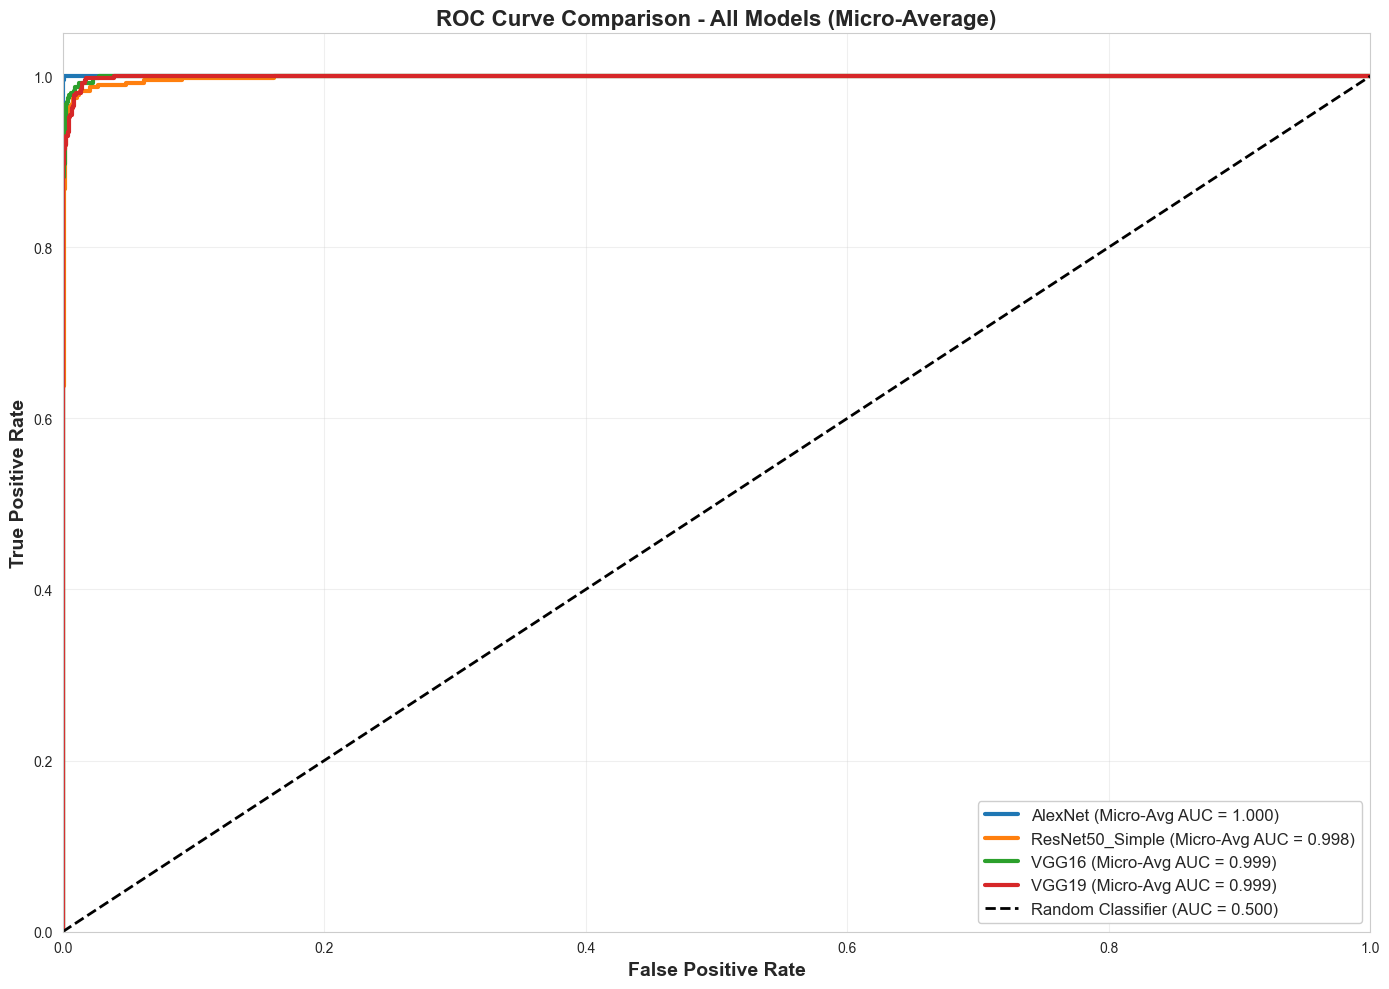


✅ Combined comparison plot saved to: /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/roc_comparison_all_models.png


In [16]:
# ============================================
# MODEL COMPARISON SUMMARY
# ============================================

if len(all_results) > 1:
    print("="*80)
    print("📊 MODEL COMPARISON SUMMARY")
    print("="*80)
    
    comparison_data = []
    for model_name, results in all_results.items():
        if results:
            comparison_data.append({
                'Model': model_name,
                'Accuracy': f"{results['accuracy']*100:.2f}%",
                'Micro-Avg AUC': f"{results['roc_auc']['micro']:.4f}",
                'Macro-Avg AUC': f"{np.mean([results['roc_auc'][i] for i in range(len(results['auc_df']))]):.4f}"
            })
    
    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))
    
    # Save comparison
    comparison_path = OUTPUTS_ROOT / 'model_comparison_auc.csv'
    comparison_df.to_csv(comparison_path, index=False)
    print(f"\n✅ Comparison saved to: {comparison_path}")
    
    # ============================================
    # Combined ROC Plot (All Models)
    # ============================================
    
    plt.figure(figsize=(14, 10))
    
    model_colors = {
        'AlexNet': '#1f77b4',
        'ResNet50_Simple': '#ff7f0e', 
        'VGG16': '#2ca02c',
        'VGG19': '#d62728'
    }
    
    for model_name, results in all_results.items():
        if results:
            color = model_colors.get(model_name, '#333333')
            micro_auc = results['roc_auc']['micro']
            plt.plot(results['fpr']['micro'], results['tpr']['micro'], 
                     color=color, lw=3,
                     label=f"{model_name} (Micro-Avg AUC = {micro_auc:.3f})")
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier (AUC = 0.500)')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
    plt.title('ROC Curve Comparison - All Models (Micro-Average)', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12, framealpha=0.95)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    
    comparison_plot_path = OUTPUTS_ROOT / 'roc_comparison_all_models.png'
    plt.savefig(comparison_plot_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ Combined comparison plot saved to: {comparison_plot_path}")

else:
    print("\n📊 Single model analyzed - no comparison available.")

## 8. Final Summary

In [17]:
# ============================================
# FINAL SUMMARY
# ============================================

print("="*80)
print("📋 FINAL SUMMARY - ROC-AUC ANALYSIS")
print("="*80)
print(f"\nDataset: {DATASET_NAME}")
print(f"Models processed: {len(all_results)}")

for model_name, results in all_results.items():
    if results:
        print(f"\n{model_name}:")
        print(f"   Test Accuracy: {results['accuracy']*100:.2f}%")
        print(f"   Micro-Avg AUC: {results['roc_auc']['micro']:.4f}")
        print(f"   Macro-Avg AUC: {np.mean([results['roc_auc'][i] for i in range(len(results['auc_df']))]):.4f}")

print("\n" + "="*80)
print("Generated Files:")
print("="*80)

for model_name in all_results.keys():
    if all_results[model_name]:
        run_dir = get_latest_run_dir(model_name)
        output_dir = OUTPUTS_ROOT / model_name / run_dir.name
        print(f"\n{model_name}:")
        print(f"   📁 {output_dir}")
        print(f"      - roc_curve_combined_{model_name}.png")
        print(f"      - roc_curves_individual_{model_name}.png")
        print(f"      - auc_scores_{model_name}.csv")
        print(f"      - auc_summary_{model_name}.csv")

print("\n" + "="*80)
print("✅ ROC-AUC ANALYSIS NOTEBOOK COMPLETE")
print("="*80)

📋 FINAL SUMMARY - ROC-AUC ANALYSIS

Dataset: MangoLeafBD
Models processed: 4

AlexNet:
   Test Accuracy: 99.50%
   Micro-Avg AUC: 1.0000
   Macro-Avg AUC: 1.0000

ResNet50_Simple:
   Test Accuracy: 96.00%
   Micro-Avg AUC: 0.9982
   Macro-Avg AUC: 0.9981

VGG16:
   Test Accuracy: 97.50%
   Micro-Avg AUC: 0.9994
   Macro-Avg AUC: 0.9995

VGG19:
   Test Accuracy: 95.50%
   Micro-Avg AUC: 0.9992
   Macro-Avg AUC: 0.9993

Generated Files:

AlexNet:
   📁 /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/AlexNet/run_3
      - roc_curve_combined_AlexNet.png
      - roc_curves_individual_AlexNet.png
      - auc_scores_AlexNet.csv
      - auc_summary_AlexNet.csv

ResNet50_Simple:
   📁 /Users/invictus/Desktop/Thesis project/thesis_draft/MangoLeafBD/outputs/ResNet50_Simple/run_15
      - roc_curve_combined_ResNet50_Simple.png
      - roc_curves_individual_ResNet50_Simple.png
      - auc_scores_ResNet50_Simple.csv
      - auc_summary_ResNet50_Simple.csv

VGG16:
   📁 /Users/in